## Smart Grid Forecaster — Data Cleaning & Exploratory Data Analysis

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns


pd.set_option('display.max_columns', None)
pd.set_option('display.width', 120)

sns.set_theme(style="whitegrid")

plt.rcParams['figure.figsize'] = (12,5)
plt.rcParams['axes.titleweight'] = 'bold'

print("Libraries loaded successfully")

Libraries loaded successfully


In [2]:
df_raw = pd.read_csv("PowerLoad_Dataset.csv")
print(f"Dataset Shape: {df_raw.shape}")
df_raw.head()

Dataset Shape: (10000, 10)


,Timestamp,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,DayOfWeek,HolidayFlag,Daily_PostDispatch_Load,Weekly_PreDispatch_Projection
0,2018-01-01 01:00:00,493.09,20.47,66.90,10.35,0.51,1,0,508.96,519.14
1,2018-01-01 04:00:00,488.29,27.66,58.72,7.86,0.02,1,0,522.95,533.41
2,2018-01-01 07:00:00,538.37,15.35,36.77,4.67,0.05,1,0,527.55,538.10
3,2018-01-01 13:00:00,404.34,22.89,83.71,11.05,0.22,1,0,506.71,516.85
4,2018-01-02 14:00:00,433.59,20.38,43.12,0.51,0.18,2,0,481.05,498.31


In [3]:
df_raw.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 10 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Timestamp                      10000 non-null  str    
 1   Power_Load_kW                  10000 non-null  float64
 2   Temperature_C                  10000 non-null  float64
 3   Humidity_%                     10000 non-null  float64
 4   WindSpeed_mps                  10000 non-null  float64
 5   Precipitation_mm               10000 non-null  float64
 6   DayOfWeek                      10000 non-null  int64  
 7   HolidayFlag                    10000 non-null  int64  
 8   Daily_PostDispatch_Load        10000 non-null  float64
 9   Weekly_PreDispatch_Projection  10000 non-null  float64
dtypes: float64(7), int64(2), str(1)
memory usage: 781.4 KB


In [4]:
df_raw.describe().T

,count,mean,std,min,25%,50%,75%,max
Power_Load_kW,10000.0,499.397814,49.880756,308.17,465.4675,499.985,532.90,680.57
Temperature_C,10000.0,25.022674,7.026358,-5.00,20.2000,25.050,29.69,45.00
Humidity_%,10000.0,60.126286,17.334169,30.00,45.0775,60.230,74.96,89.99
WindSpeed_mps,10000.0,7.516845,4.346676,0.00,3.7575,7.560,11.27,15.00
Precipitation_mm,10000.0,0.202565,0.204053,0.00,0.0600,0.140,0.28,2.16
DayOfWeek,10000.0,3.982500,2.010771,1.00,2.0000,4.000,6.00,7.00
HolidayFlag,10000.0,0.285400,0.451627,0.00,0.0000,0.000,1.00,1.00
Daily_PostDispatch_Load,10000.0,500.112020,10.137719,463.76,493.3300,500.110,506.77,539.85
Weekly_PreDispatch_Projection,10000.0,509.946114,3.916816,493.59,507.3700,510.030,512.57,538.10


### Data Quality Assessment

In [5]:
missing = df_raw.isnull().sum()

missing[missing>0]

Series([], dtype: int64)

In [6]:
print(
    "Duplicate rows:",
    df_raw.duplicated().sum()
)

Duplicate rows: 0


In [7]:
timestamp_check = pd.to_datetime(df_raw['Timestamp'])

print(
    "Duplicate timestamps:",
    timestamp_check.duplicated().sum()
)

Duplicate timestamps: 0


In [8]:
# Validate Weather Values
print(
"humidity_outside_0_100 : ",
    ((df_raw["Humidity_%"]<0) |
        (df_raw["Humidity_%"]>100)).sum())
print(
"negative_wind_speed : ",
    (df_raw["WindSpeed_mps"]<0).sum())

print(
"negative_precipitation : ",
    (df_raw["Precipitation_mm"]<0).sum())


humidity_outside_0_100 :  0
negative_wind_speed :  0
negative_precipitation :  0


### Time Stamp Processing

In [9]:
df = df_raw.copy()

df['Timestamp'] = pd.to_datetime(df['Timestamp'])

df = df.sort_values(
    'Timestamp'
).reset_index(drop=True)


df.head()

,Timestamp,Power_Load_kW,Temperature_C,Humidity_%,WindSpeed_mps,Precipitation_mm,DayOfWeek,HolidayFlag,Daily_PostDispatch_Load,Weekly_PreDispatch_Projection
0,2018-01-01 01:00:00,493.09,20.47,66.90,10.35,0.51,1,0,508.96,519.14
1,2018-01-01 04:00:00,488.29,27.66,58.72,7.86,0.02,1,0,522.95,533.41
2,2018-01-01 07:00:00,538.37,15.35,36.77,4.67,0.05,1,0,527.55,538.10
3,2018-01-01 13:00:00,404.34,22.89,83.71,11.05,0.22,1,0,506.71,516.85
4,2018-01-02 14:00:00,433.59,20.38,43.12,0.51,0.18,2,0,481.05,498.31


In [10]:
##Missing Hour Analysis

start = df['Timestamp'].min()
end = df['Timestamp'].max()


full_range = pd.date_range(
    start=start,
    end=end,
    freq="h"
)


print("Start:",start)
print("End:",end)

print(
    "Expected hourly records:",
    len(full_range)
)

print(
    "Actual records:",
    len(df)
)

Start: 2018-01-01 01:00:00
End: 2023-06-30 16:00:00
Expected hourly records: 48160
Actual records: 10000


In [11]:
missing_timestamps = full_range.difference(df['Timestamp'])
print(f"Missing timestamps: {len(missing_timestamps):,}")
pd.DataFrame({'Timestamp': missing_timestamps}).to_csv(
    "missing_timestamps.csv", index=False
)

Missing timestamps: 38,160


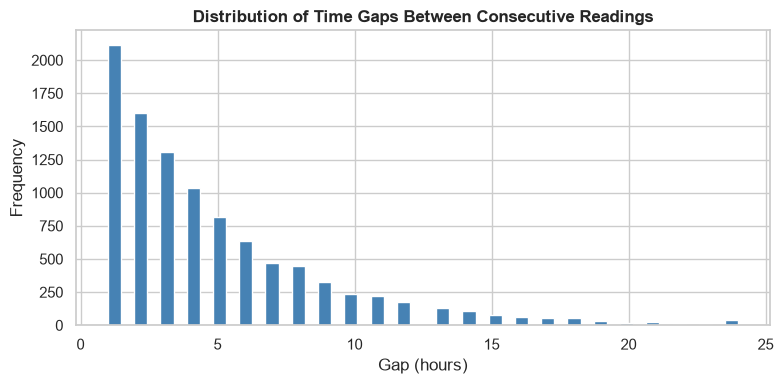

count    9999.000000
mean        4.816382
std         4.265176
min         1.000000
25%         2.000000
50%         3.000000
75%         6.000000
max        47.000000
Name: Timestamp, dtype: float64


In [12]:
gap_hours = df['Timestamp'].diff().dropna().dt.total_seconds() / 3600

plt.figure(figsize=(8, 4))
gap_hours.clip(upper=24).plot(kind='hist', bins=48, color='steelblue')

plt.title("Distribution of Time Gaps Between Consecutive Readings")
plt.xlabel("Gap (hours)")
plt.ylabel("Frequency")
plt.tight_layout()
plt.show()

print(gap_hours.describe())

### Missing Timestamp Handling

**Decision: Retain only real observations — no full-hourly reindexing or interpolation.**

The dataset contains approximately 10,000 observed hourly records out of the 48,160 hours within its overall date range, representing only about 21% coverage. Performing full-hourly reindexing would require creating approximately 38,000 synthetic rows, meaning nearly 79% of the resulting dataset would consist of artificially generated values rather than actual observations.

Such extensive interpolation is not academically justifiable for a forecasting project because the interpolated values are estimates, not real measurements. Training a forecasting model on predominantly synthetic data could introduce bias and reduce the reliability of the results, as the model would learn patterns from values that were never observed. Therefore, only the original observed records were retained, and all subsequent preprocessing, feature engineering, and model development were performed exclusively on these real observations.


In [13]:
df_clean = df.copy()

coverage_pct = 100 * len(df_clean) / len(full_range)

print(f"Real observations retained: {len(df_clean):,}")
print(f"Theoretical full hourly timeline: {len(full_range):,}")
print(f"Coverage: {coverage_pct:.1f}% of the full hourly timeline")


Real observations retained: 10,000
Theoretical full hourly timeline: 48,160
Coverage: 20.8% of the full hourly timeline


In [14]:
df_clean['HolidayFlag'] = df_clean['HolidayFlag'].astype(int)

# Sanity check: HolidayFlag should not be perfectly redundant with IsWeekend for
# a genuine holiday feature. We check this explicitly once IsWeekend is built below.

df_clean.shape


(10000, 10)

### Feature Engineering

In [15]:
df_clean['Hour'] = (df_clean['Timestamp'].dt.hour)
df_clean['DayOfWeek'] = (df_clean['Timestamp'].dt.dayofweek + 1)
df_clean['IsWeekend'] = (df_clean['DayOfWeek'].isin([6,7]).astype(int))
df_clean['Month'] = (df_clean['Timestamp'].dt.month)
df_clean['Year'] = (df_clean['Timestamp'].dt.year)

# Known data-quality issue: HolidayFlag is a perfect duplicate of IsWeekend in
# this dataset (it only flags weekends, not actual Sri Lankan public holidays).
# Confirmed below - correlation of 1.0 means HolidayFlag currently carries no
# information beyond IsWeekend. Treated as a documented limitation rather than
# silently fixed, since resolving it properly requires an external Sri Lankan
# public holiday calendar merged in by date.
flag_corr = df_clean['HolidayFlag'].corr(df_clean['IsWeekend'])
print(f"Correlation between HolidayFlag and IsWeekend: {flag_corr:.3f}")
if flag_corr == 1.0:
    print("WARNING: HolidayFlag is a perfect duplicate of IsWeekend - it does not "
          "represent true public holidays. See limitations note.")

# Lag features, computed against a continuous hourly grid so "previous hour"
# and "previous day" always mean exactly that. Because we only retain real
# observations, this hourly grid has gaps - a lag value comes back as NaN
# whenever the true previous hour/day was never actually recorded, rather
# than silently pulling a wrong-but-plausible number from several hours or
# days earlier.
_hourly_series = (
    df_clean
    .set_index('Timestamp')['Power_Load_kW']
    .reindex(pd.date_range(df_clean['Timestamp'].min(), df_clean['Timestamp'].max(), freq='h'))
)

df_clean['Load_previous_hour'] = (
    _hourly_series.shift(1).reindex(df_clean['Timestamp']).values
)

df_clean['Load_previous_day'] = (
    _hourly_series.shift(24).reindex(df_clean['Timestamp']).values
)

n_lag_available = df_clean['Load_previous_hour'].notna().sum()
print(f"Load_previous_hour available for {n_lag_available:,} / {len(df_clean):,} rows "
      f"({100*n_lag_available/len(df_clean):.1f}%) - the rest are NaN because the "
      f"prior hour was not actually recorded (expected, given ~21% timeline coverage).")


Correlation between HolidayFlag and IsWeekend: 1.000
Load_previous_hour available for 2,118 / 10,000 rows (21.2%) - the rest are NaN because the prior hour was not actually recorded (expected, given ~21% timeline coverage).


### Outlier Detection

Each column gets a treatment suited to what it physically represents, rather than one
blanket rule applied everywhere:

- **Power_Load_kW** (the forecast target): percentile winsorization (1st/99th) for broad
  extremes, plus rolling-median imputation for isolated single-point spikes that a global
  percentile cut would miss.
- **Weekly_PreDispatch_Projection**: percentile winsorization (1st/99th), same rationale
  as the target it's meant to project.
- **Temperature_C**: physical range clipping to plausible Sri Lankan ambient temperatures,
  rather than a statistical rule that could clip genuine hot/cold days.
- **Precipitation_mm**: left as-is here; a log1p transform (below) is used instead of
  clipping, since rainfall is naturally right-skewed and heavy-rain values are real events,
  not errors.
- **Daily_PostDispatch_Load**: IQR-based winsorization, as a general-purpose fallback for
  a derived/reported column with no obvious physical bound.


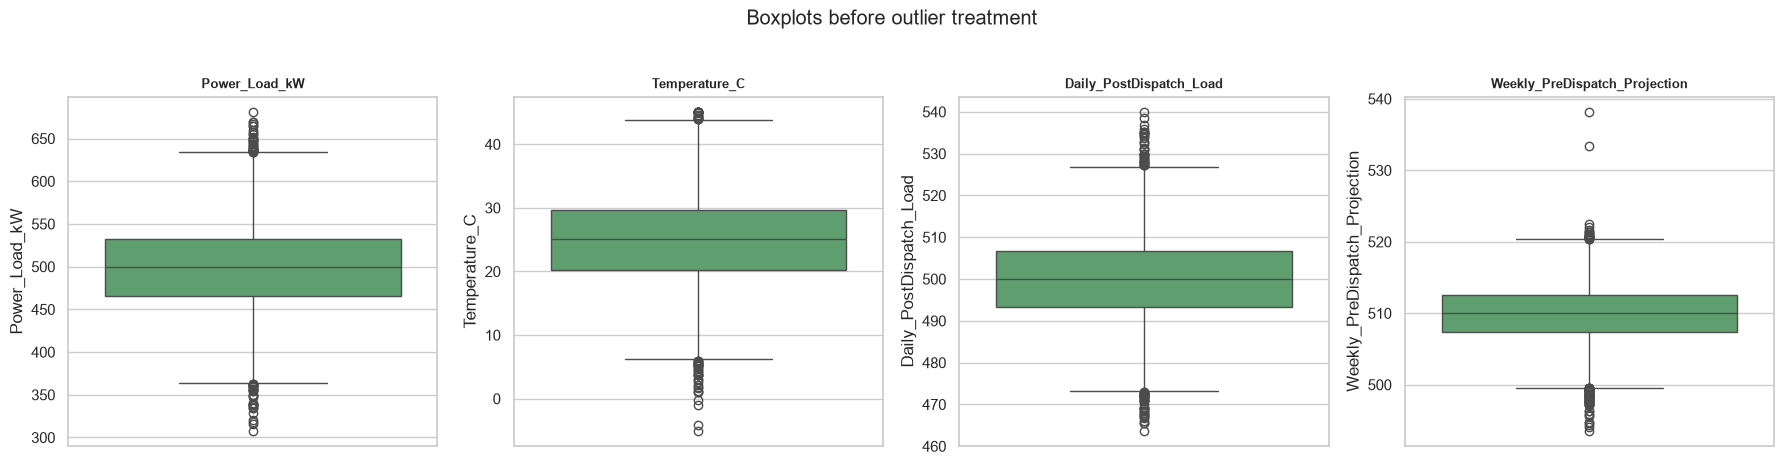

In [16]:
review_cols = ['Power_Load_kW', 'Temperature_C', 'Daily_PostDispatch_Load', 'Weekly_PreDispatch_Projection']

fig, axes = plt.subplots(1, len(review_cols), figsize=(18, 4.5))
for ax, col in zip(axes, review_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color='#55A868')
    ax.set_title(col, fontsize=9)
plt.suptitle('Boxplots before outlier treatment', y=1.03)
plt.tight_layout()
plt.show()


In [17]:
outlier_summary = {}

# --- Power_Load_kW: percentile winsorization + rolling-median spike fix ---
p_low, p_high = df_clean['Power_Load_kW'].quantile([0.01, 0.99])
n_winsorized = ((df_clean['Power_Load_kW'] < p_low) | (df_clean['Power_Load_kW'] > p_high)).sum()
df_clean['Power_Load_kW'] = df_clean['Power_Load_kW'].clip(lower=p_low, upper=p_high)

# Isolated single-point spikes: points that deviate sharply from their local
# neighborhood (rolling median) even if within the global percentile bounds.
rolling_med = df_clean['Power_Load_kW'].rolling(window=5, center=True, min_periods=3).median()
spike_mask = (df_clean['Power_Load_kW'] - rolling_med).abs() > 3 * df_clean['Power_Load_kW'].std()
n_spikes = spike_mask.sum()
df_clean.loc[spike_mask, 'Power_Load_kW'] = rolling_med[spike_mask]
outlier_summary['Power_Load_kW'] = n_winsorized + n_spikes

# --- Weekly_PreDispatch_Projection: percentile winsorization ---
p_low, p_high = df_clean['Weekly_PreDispatch_Projection'].quantile([0.01, 0.99])
n = ((df_clean['Weekly_PreDispatch_Projection'] < p_low) | (df_clean['Weekly_PreDispatch_Projection'] > p_high)).sum()
df_clean['Weekly_PreDispatch_Projection'] = df_clean['Weekly_PreDispatch_Projection'].clip(lower=p_low, upper=p_high)
outlier_summary['Weekly_PreDispatch_Projection'] = n

# --- Temperature_C: physical range clipping (plausible Sri Lankan range) ---
TEMP_MIN, TEMP_MAX = 15.0, 40.0
n = ((df_clean['Temperature_C'] < TEMP_MIN) | (df_clean['Temperature_C'] > TEMP_MAX)).sum()
df_clean['Temperature_C'] = df_clean['Temperature_C'].clip(lower=TEMP_MIN, upper=TEMP_MAX)
outlier_summary['Temperature_C'] = n

# --- Daily_PostDispatch_Load: IQR-based winsorization (fallback, no physical bound) ---
Q1 = df_clean['Daily_PostDispatch_Load'].quantile(.25)
Q3 = df_clean['Daily_PostDispatch_Load'].quantile(.75)
IQR = Q3 - Q1
lower, upper = Q1 - 1.5 * IQR, Q3 + 1.5 * IQR
n = ((df_clean['Daily_PostDispatch_Load'] < lower) | (df_clean['Daily_PostDispatch_Load'] > upper)).sum()
df_clean['Daily_PostDispatch_Load'] = df_clean['Daily_PostDispatch_Load'].clip(lower=lower, upper=upper)
outlier_summary['Daily_PostDispatch_Load'] = n

# Precipitation_mm is intentionally NOT clipped here - see log1p transform below.

pd.Series(outlier_summary, name='outliers_treated')


Power_Load_kW                    219
Weekly_PreDispatch_Projection    199
Temperature_C                    909
Daily_PostDispatch_Load           82
Name: outliers_treated, dtype: int64

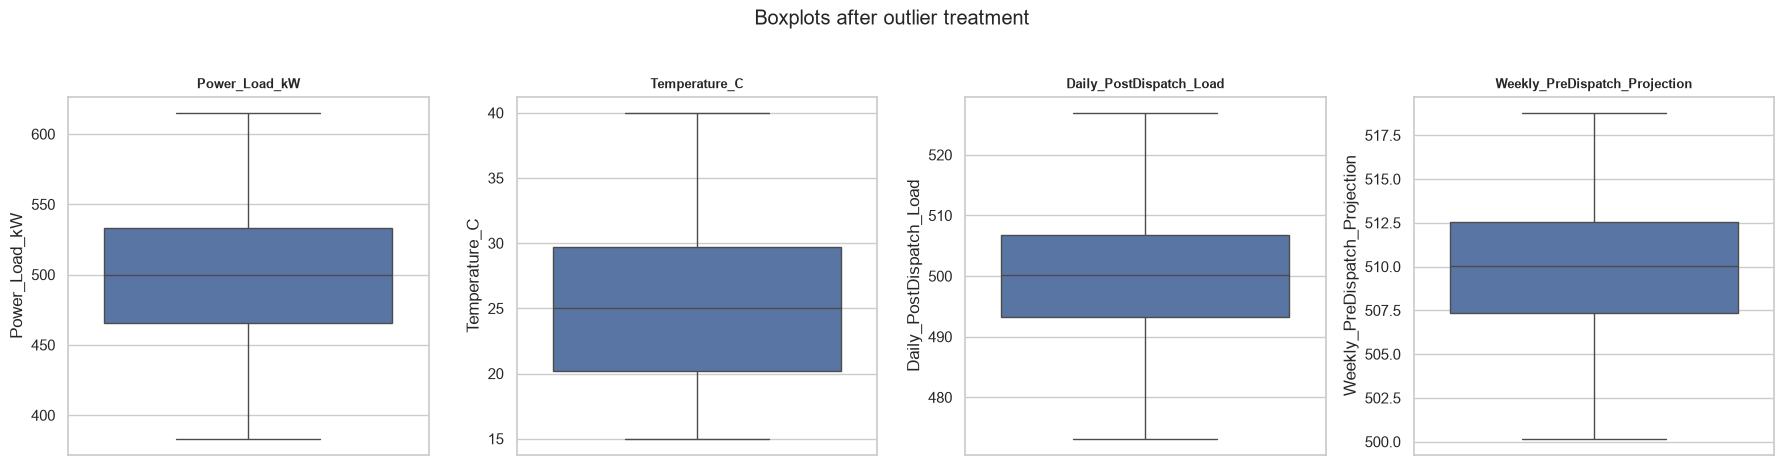

In [18]:
fig, axes = plt.subplots(1, len(review_cols), figsize=(18, 4.5))
for ax, col in zip(axes, review_cols):
    sns.boxplot(y=df_clean[col], ax=ax, color='#4C72B0')
    ax.set_title(col, fontsize=9)
plt.suptitle('Boxplots after outlier treatment', y=1.03)
plt.tight_layout()
plt.show()


In [19]:
# Reduces skewness caused by extreme rainfall values.
df_clean['Precipitation_mm_log'] = np.log1p(df_clean['Precipitation_mm'])

### Final Dataset Export

In [20]:
# Final sorting

final_order = [
    'Timestamp',
    'Year',
    'Month',
    'DayOfWeek',
    'IsWeekend',
    'Hour',
    'HolidayFlag',
    'Power_Load_kW',
    'Temperature_C',
    'Humidity_%',
    'WindSpeed_mps',
    'Precipitation_mm',
    'Precipitation_mm_log',
    'Daily_PostDispatch_Load',
    'Weekly_PreDispatch_Projection',
    'Load_previous_hour',
    'Load_previous_day'
]

df_clean = df_clean[final_order]

numeric_cols = df_clean.select_dtypes(include=['float64']).columns
df_clean[numeric_cols] = df_clean[numeric_cols].round(2)

# Export cleaned dataset
df_clean.to_csv("cleaned_load_data.csv", index=False)

print("Final cleaned dataset saved to", "cleaned_load_data.csv")
print(f"Shape: {df_clean.shape[0]:,} rows x {df_clean.shape[1]} columns")
print(f"All {df_clean.shape[0]:,} rows are real observations - no interpolated/synthetic rows.")


Final cleaned dataset saved to cleaned_load_data.csv
Shape: 10,000 rows x 17 columns
All 10,000 rows are real observations - no interpolated/synthetic rows.


### EDA

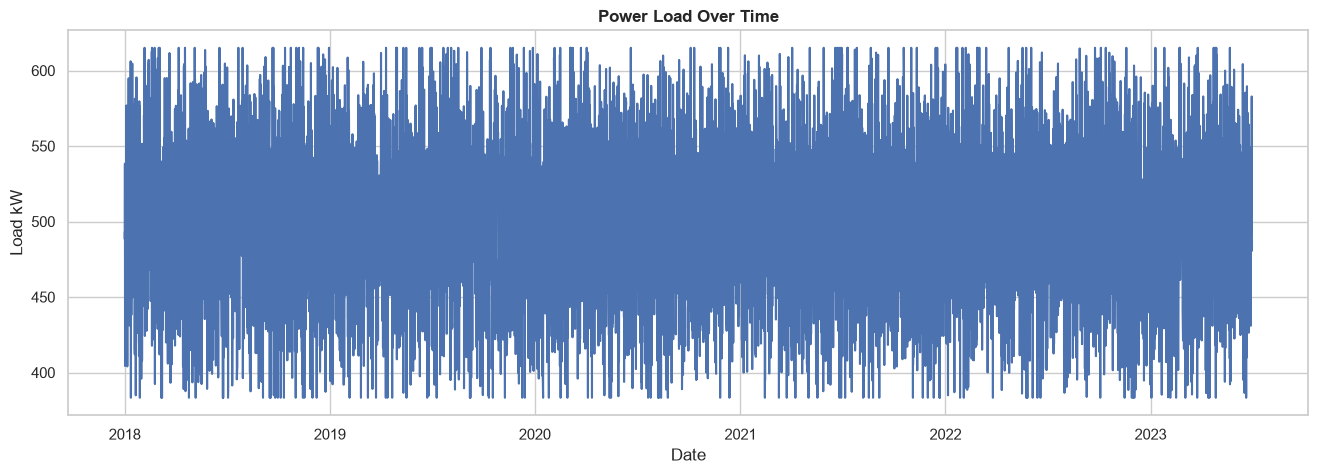

In [21]:
plt.figure(figsize=(16,5))

plt.plot(df_clean['Timestamp'],df_clean['Power_Load_kW'])
plt.title("Power Load Over Time")
plt.xlabel("Date")
plt.ylabel("Load kW")

plt.show()

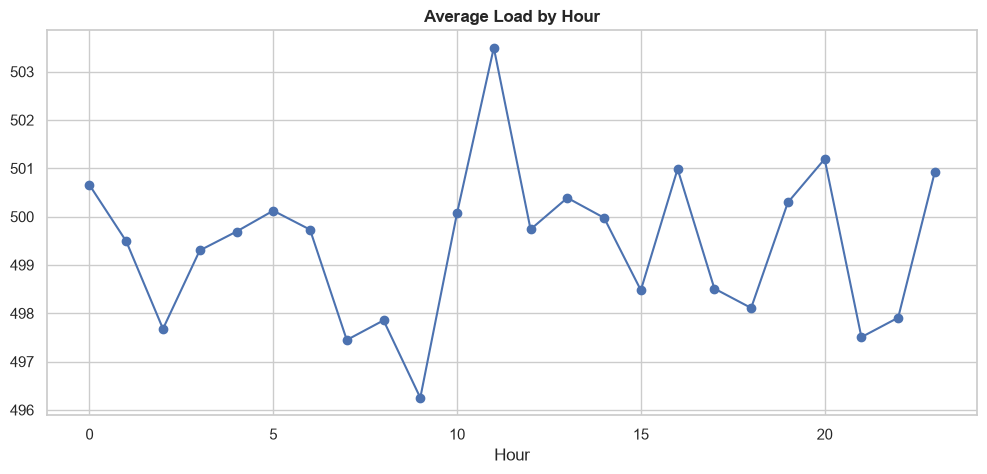

In [22]:
hourly_avg = (df_clean.groupby('Hour')['Power_Load_kW'].mean())
hourly_avg.plot(marker='o')
plt.title("Average Load by Hour")

plt.show()

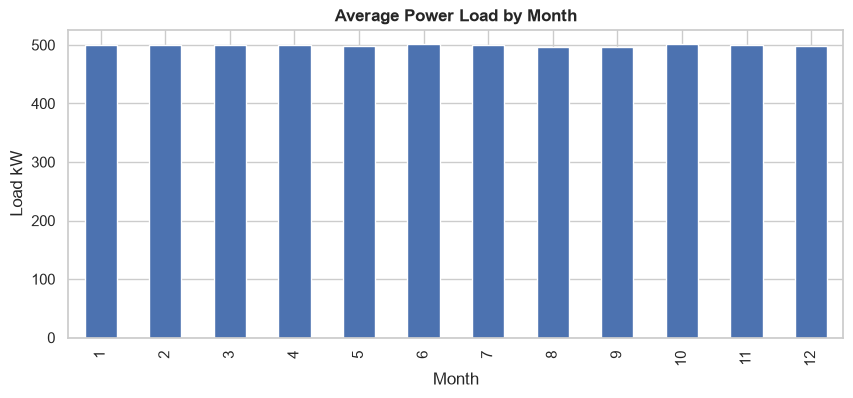

In [23]:
monthly_load = (
    df_clean
    .groupby('Month')['Power_Load_kW']
    .mean()
)


monthly_load.plot(
    kind='bar',
    figsize=(10,4)
)

plt.title("Average Power Load by Month")
plt.xlabel("Month")
plt.ylabel("Load kW")

plt.show()

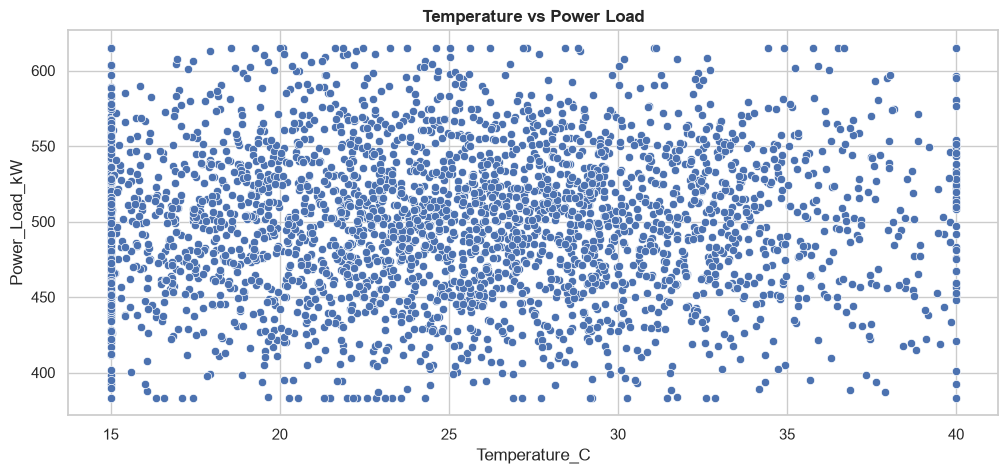

In [24]:
sns.scatterplot(
    data=df_clean.sample(3000),
    x='Temperature_C',
    y='Power_Load_kW'
)

plt.title(
    "Temperature vs Power Load"
)

plt.show()

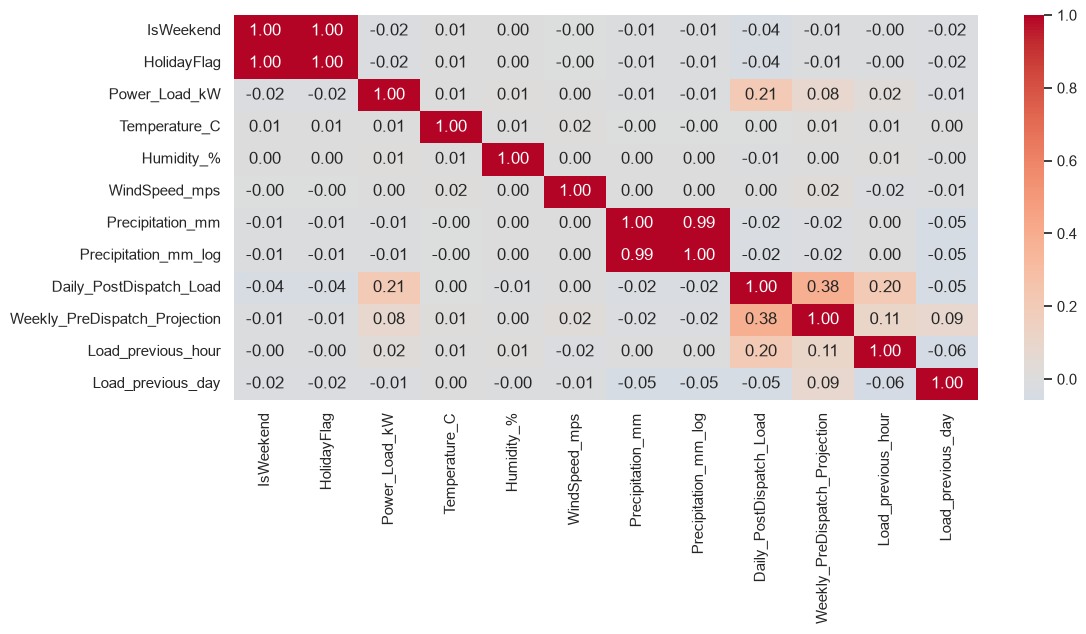

In [25]:
corr_cols = df_clean.select_dtypes(
    include=['int64', 'float64']
).columns

sns.heatmap(
    df_clean[corr_cols].corr(),
    annot=True,
    fmt=".2f",
    cmap="coolwarm",
    center=0
)

plt.show()

### EDA Findings & Limitations


In [26]:
summary = {}

summary['yearly'] = df_clean.groupby('Year')['Power_Load_kW'].mean()
summary['monthly'] = df_clean.groupby('Month')['Power_Load_kW'].mean()
summary['hourly'] = df_clean.groupby('Hour')['Power_Load_kW'].mean()
summary['weekend'] = df_clean.groupby('IsWeekend')['Power_Load_kW'].mean()

print("Yearly average load range:", f"{summary['yearly'].min():.1f} - {summary['yearly'].max():.1f} kW")
print("Monthly average load range:", f"{summary['monthly'].min():.1f} - {summary['monthly'].max():.1f} kW")
print("Hourly average load range:", f"{summary['hourly'].min():.1f} - {summary['hourly'].max():.1f} kW")
print("Weekday vs weekend average load:", f"{summary['weekend'][0]:.1f} vs {summary['weekend'][1]:.1f} kW")

weather_corr = df_clean[['Power_Load_kW','Temperature_C','Humidity_%','WindSpeed_mps','Precipitation_mm']].corr()['Power_Load_kW']
print("\nCorrelation of Power_Load_kW with weather variables:")
print(weather_corr)


Yearly average load range: 498.5 - 500.1 kW
Monthly average load range: 497.1 - 501.2 kW
Hourly average load range: 496.3 - 503.5 kW
Weekday vs weekend average load: 500.0 vs 498.0 kW

Correlation of Power_Load_kW with weather variables:
Power_Load_kW       1.000000
Temperature_C       0.007815
Humidity_%          0.010511
WindSpeed_mps       0.003711
Precipitation_mm   -0.005774
Name: Power_Load_kW, dtype: float64


**Observed pattern: the dataset shows essentially no exploitable structure.**

- No meaningful yearly trend (2018-2023 averages sit within a narrow band of each other).
- No seasonal/monthly pattern (all months average within a few kW of the overall mean).
- No diurnal pattern (hourly averages are flat across all 24 hours - no morning/evening
  peaks, unlike real grid load).
- Negligible weekday/weekend difference.
- Near-zero correlation between `Power_Load_kW` and all weather variables (temperature,
  humidity, wind speed, precipitation) - all |r| well under 0.05.

**Implication for modeling**: this points to `Power_Load_kW` behaving like noise sampled
around a fixed mean, rather than data generated by real, learnable demand drivers
(time-of-day, seasonality, weather). Any forecaster trained on this (XGBoost, Prophet)
should be benchmarked against a naive baseline (e.g. rolling mean or persistence), since
a low ceiling on forecastability here is a property of the data, not necessarily a
modeling failure. This is a limitation worth stating explicitly in the report/viva rather
than implying the models underperformed due to poor feature engineering.
